In [75]:
import string
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import spacy
nlp = spacy.load('es_core_news_sm', disable=['parser', 'ner'])

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\valde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\valde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\valde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [76]:
df = pd.read_csv('df_total.csv')

TEXT_COL = "news"
CATEGORY_COL = "Type"

print(df.shape)
df.head()

(1217, 3)


,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra


**¿Cuántos documentos tiene el corpus?:** El corpus contiene 1,217 documentos.

**¿Qué columnas contiene y qué información guarda cada una?:** El corpus contiene 3 columnas en donde se guarda el url, texto de la noticia (news) y una etiqueta que hace referencia al tipo de noticia (type).

Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64


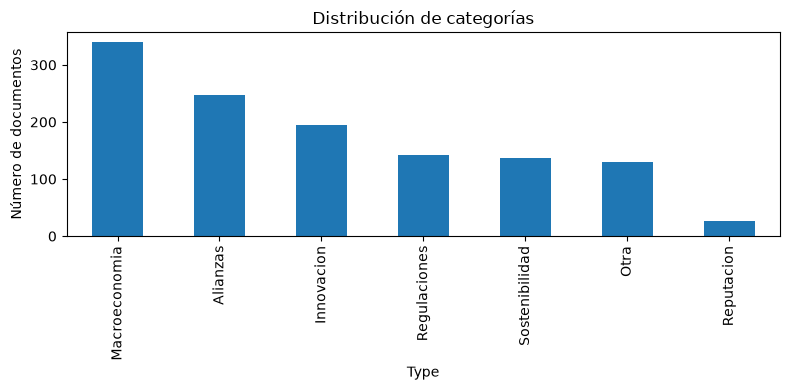

In [77]:
categorias = df[CATEGORY_COL].value_counts()
print(categorias)

categorias.plot(kind='bar', figsize=(8,4), title='Distribución de categorías')
plt.ylabel('Número de documentos')
plt.tight_layout()
plt.show()

**¿Cuántas categorías hay y cómo se distribuyen?:** Existen 7 categorias unicas con la siguiente distribucion:
- Macroeconomia: 27.9%
- Alianzas: 20.3%
- Innovacion: 16.0%
- Regulaciones: 11.7%
- Sostenibilidad: 11.2%
- Otra: 10.7%
- Reputacion: 2.1%

In [78]:
# ¿Hay filas vacías o duplicadas?
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nFilas completamente duplicadas:", df.duplicated().sum())
print("Textos duplicados:", df.duplicated(subset=[TEXT_COL]).sum())

Valores nulos por columna:
url     0
news    4
Type    0
dtype: int64

Filas completamente duplicadas: 75
Textos duplicados: 79


**¿Hay filas vacías o duplicadas?:** Se identificaron 4 filas con valores nulos en la columna 'news'. Además, existen 75 filas completamente duplicadas y se encontraron 79 registros con contenido duplicado en la columna 'news'.

In [79]:
df = df.dropna(subset=[TEXT_COL]).drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
print("Shape final:", df.shape)

Shape final: (1137, 3)


---

In [80]:
def contar_tokens_tipos(columna_de_listas):
    todos = [tok for lista in columna_de_listas for tok in lista]
    return len(todos), len(set(todos))

pasos = []

In [81]:
# i. Tokenización
df['tokens'] = df[TEXT_COL].astype(str).apply(lambda x: word_tokenize(x, language='spanish'))
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Tokenización', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 631733 | Tipos: 38947


In [82]:
# ii. Minúsculas
df['tokens'] = df['tokens'].apply(lambda toks: [w.lower() for w in toks])
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Minúsculas', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 631733 | Tipos: 36099


In [83]:
# iii. Eliminar puntuación
puntuacion = set(string.punctuation) | {'¿','¡','—','–','…','“','”','‘','’','»','«'}

def es_puntuacion(tok):
    return all(ch in puntuacion for ch in tok)

df['tokens'] = df['tokens'].apply(lambda toks: [w for w in toks if not es_puntuacion(w)])
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Sin puntuación', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 598379 | Tipos: 36066


In [84]:
# iv. Eliminar stopwords
stop_es = set(stopwords.words('spanish'))
df['tokens'] = df['tokens'].apply(lambda toks: [w for w in toks if w not in stop_es])
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Sin stopwords', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 318955 | Tipos: 35855


In [85]:
# v. Lematizar
textos_para_lematizar = df['tokens'].apply(lambda toks: ' '.join(toks))

lemas = []
for doc in nlp.pipe(textos_para_lematizar, batch_size=64):
    lemas.append([t.lemma_.lower() for t in doc if t.lemma_.strip() != ''])

df['tokens'] = lemas
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Lematizado', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 319421 | Tipos: 28806


In [86]:
pipeline = pd.DataFrame(pasos, columns=['Paso', 'Tokens', 'Tipos'])
pipeline['Tipo/Token'] = (pipeline['Tipos'] / pipeline['Tokens']).round(4)
pipeline

,Paso,Tokens,Tipos,Tipo/Token
0,Tokenización,631733,38947,0.0617
1,Minúsculas,631733,36099,0.0571
2,Sin puntuación,598379,36066,0.0603
3,Sin stopwords,318955,35855,0.1124
4,Lematizado,319421,28806,0.0902


---

EDA del corpus

In [87]:
# Tokens y tipos antes y después de la normalización

tokens_antes, tipos_antes = pasos[0][1], pasos[0][2]
tokens_despues, tipos_despues = pasos[-1][1], pasos[-1][2]

reduccion_vocab = (tipos_antes - tipos_despues) / tipos_antes * 100

print(f"Antes de normalizar   -> Tokens: {tokens_antes} | Tipos: {tipos_antes}")
print(f"Después de normalizar -> Tokens: {tokens_despues} | Tipos: {tipos_despues}")
print(f"Reducción del vocabulario: {reduccion_vocab:.1f}%")

Antes de normalizar   -> Tokens: 631733 | Tipos: 38947
Después de normalizar -> Tokens: 319421 | Tipos: 28806
Reducción del vocabulario: 26.0%


In [88]:
# Riqueza léxica

ttr_global = tipos_despues / tokens_despues
print(f"TTR global: {ttr_global:.4f}")

def ttr_por_categoria(df):
    resultados = {}
    for cat, grupo in df.groupby(CATEGORY_COL):
        todos = [tok for toks in grupo['tokens'] for tok in toks]
        resultados[cat] = len(set(todos)) / len(todos) if len(todos) > 0 else 0
    return pd.Series(resultados).sort_values(ascending=False)

ttr_categoria = ttr_por_categoria(df)
ttr_categoria

TTR global: 0.0902


Reputacion        0.350727
Regulaciones      0.216135
Otra              0.204993
Alianzas          0.203608
Sostenibilidad    0.154691
Innovacion        0.139511
Macroeconomia     0.127567
dtype: float64

In [89]:
# Top 20 palabras más frecuentes

all_tokens = [tok for toks in df['tokens'] for tok in toks]
frecuencias = Counter(all_tokens)

top20 = pd.DataFrame(frecuencias.most_common(20), columns=['Palabra', 'Frecuencia'])
top20

,Palabra,Frecuencia
0,poder,2398
1,bbva,2149
2,año,2022
3,banco,1463
4,país,1397
5,inflación,1348
6,empresa,1295
7,nuevo,1216
8,precio,1199
9,ser,1198


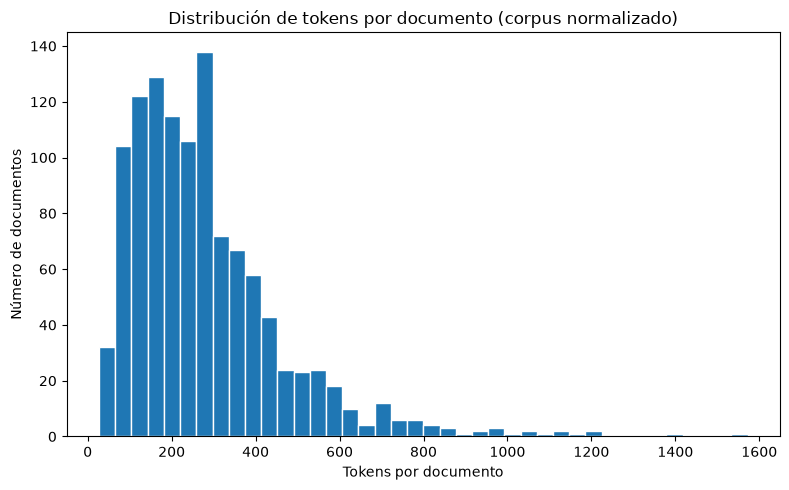

In [90]:
# Histograma de tokens por documento

df['n_tokens'] = df['tokens'].apply(len)

plt.figure(figsize=(8,5))
plt.hist(df['n_tokens'], bins=40, edgecolor='white')
plt.xlabel('Tokens por documento')
plt.ylabel('Número de documentos')
plt.title('Distribución de tokens por documento (corpus normalizado)')
plt.tight_layout()
plt.show()

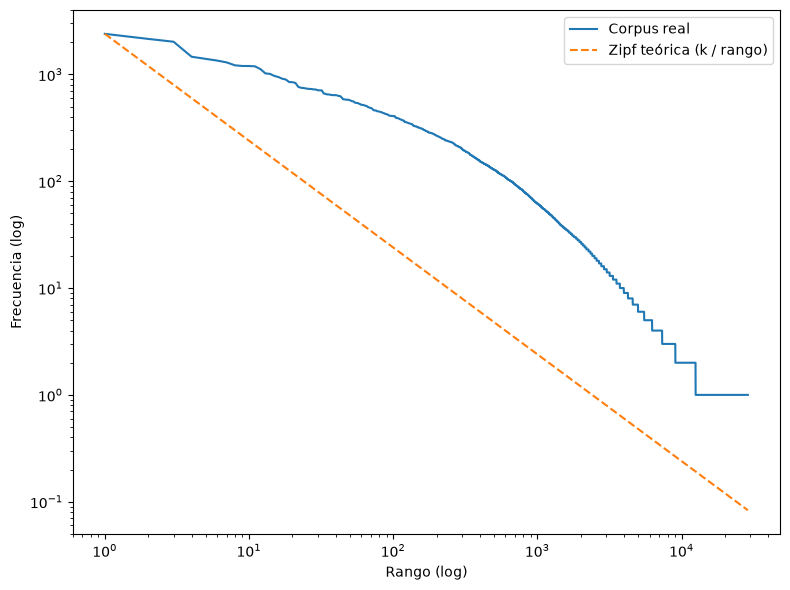

In [91]:
# Ley de Zipf: corpus real vs. curva teórica

frecuencias_ordenadas = np.array([f for _, f in frecuencias.most_common()])
rangos = np.arange(1, len(frecuencias_ordenadas) + 1)

k = frecuencias_ordenadas[0]
zipf_teorica = k / rangos

plt.figure(figsize=(8,6))
plt.loglog(rangos, frecuencias_ordenadas, label='Corpus real')
plt.loglog(rangos, zipf_teorica, linestyle='--', label='Zipf teórica (k / rango)')
plt.xlabel('Rango (log)')
plt.ylabel('Frecuencia (log)')
plt.legend()
plt.tight_layout()
plt.show()

In [92]:
# Comparación por categoría (top 10 palabras mas frecuentes)

categorias_a_comparar = ["Macroeconomia", "Innovacion"]
for cat in categorias_a_comparar:
    tokens_cat = [tok for toks in df[df[CATEGORY_COL] == cat]['tokens'] for tok in toks]
    top10_cat = Counter(tokens_cat).most_common(10)
    print(f"\nTop 10 — {cat}:")
    for palabra, freq in top10_cat:
        print(f"  {palabra}: {freq}")


Top 10 — Macroeconomia:
  inflación: 1278
  precio: 986
  año: 905
  poder: 666
  tasa: 507
  mayor: 507
  bbva: 494
  mes: 489
  país: 430
  aumento: 416

Top 10 — Innovacion:
  bbva: 886
  poder: 496
  banco: 352
  digital: 338
  cliente: 323
  nuevo: 314
  dato: 298
  empresa: 283
  permitir: 259
  financiero: 247


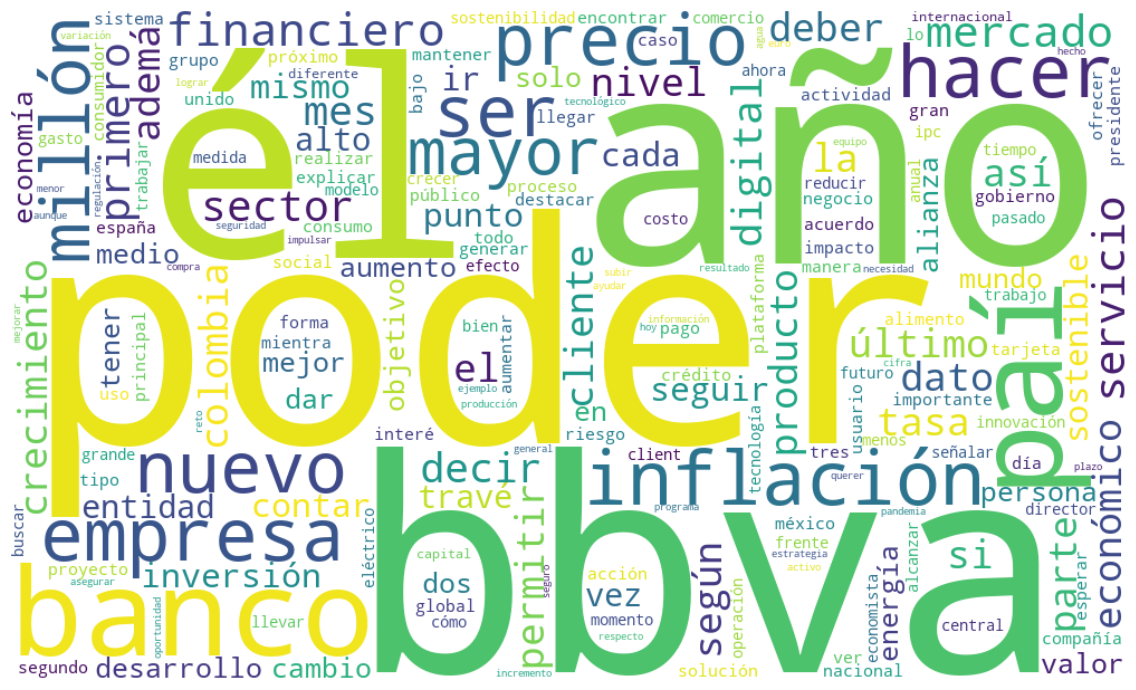

In [93]:
# Nube de palabras del vocabulario normalizado

from wordcloud import WordCloud

texto_completo = ' '.join(all_tokens)
wc = WordCloud(width=1000, height=600, background_color='white', collocations=False).generate(texto_completo)

plt.figure(figsize=(12,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()